# Opening a FITS image from S3

In this notebook, we demonstrate **how to read a FITS file from an AWS S3 bucket** rather than through the JupyterHub mount. Reading the data directly from the S3 bucket is generally the preferred data access mechanism. The mount points are provided as a convienence but not generally recommended for production-level workflows. 

An important point to stress is that**the image stays in the bucket and you reach into it**, pulling only the pixels you are going to look at. This notebook opens one such image straight from S3 and **displays a cutout of it without ever transferring the whole file.** Moreover, the image is not copied to a user's home directory, minimizing duplicate storageo of data.

We will use a A DSA continuum image (about 2 GB) as an example. T

Browse the [notebooks index](README.md).

**At a glance** · Starter · Packages: `astropy`, `s3fs`, `matplotlib`

- **Question:** How do I open, inspect and view a FITS image that lives in an S3 bucket, and how
  do I avoid pulling two gigabytes to look at a few arcminutes of sky?
- **Prerequisite:** Run this on the symposium JupyterHub, where credentials and the data are
  already in place. Off the hub you need AWS credentials for the bucket; the bucket is private,
  so unauthenticated access will not work.
- **Takeaway:** `hdu.section` instead of `hdu.data`, and why that one change is the difference
  between 2 MB and 2.2 GB.

## Parameters
Change these inputs first; leave the calculation cells intact.

In [1]:
BUCKET = "schmidt-observatory-system"
SAMPLE_FILE = "dsa/v2-convening/mockfm_DPR-DSA-03_mp37_701.235_20260922.fits"
MOUNT = "~/s3"      # the bucket is also NFS-mounted here on the hub
CUTOUT = 256        # cutout size in pixels, per side

## 1. Two methods for reading the same FITS data

The sample data provided are stored in the Amazon Web Services (AWS) cloud using their Simple Storage Services (S3) object storage system. The data can be accessed in two ways:

**(1) The AWS S3 API**: Using this data access mechanism, the `astropy.io.fits` package will use `s3fs` to read the data. More details are provided in the [astropy.io.fits](https://docs.astropy.org/en/latest/io/fits/index.html). This is the most code-portable option and generally the recommended mechanism for reading data from S3.

In [2]:
# Example of reading FITS data directly from S3 using the AWS S3 API

import os, time
from astropy.io import fits

s3_url = f"s3://{BUCKET}/{SAMPLE_FILE}"
mount_path = os.path.expanduser(f"{MOUNT}/{BUCKET}/{SAMPLE_FILE}")

t0 = time.perf_counter()
hdul = fits.open(s3_url, use_fsspec=True)
print(f"opened over the S3 API in {time.perf_counter() - t0:.2f} s")

hdu = hdul[0]
hdr = hdu.header
print(f"file is {hdr['NAXIS1'] * hdr['NAXIS2'] * abs(hdr['BITPIX']) / 8 / 1024**3:.2f} GiB of pixels")

opened over the S3 API in 1.25 s
file is 2.21 GiB of pixels


**(2) The file system mount point**: The path at `~/s3/schmidt-observatory-system/` makes the bucket look like an ordinary directory, so `fits.open` takes a normal file system path. It is convenient, faster, and abstracts away the S3 storage, but it exists only inside this hub and is generally a less stable .

In [3]:
# The same file through the mount, for comparison. Only available on the hub.
if os.path.exists(mount_path):
    t0 = time.perf_counter()
    with fits.open(mount_path) as local:
        probe_mount = local[0].section[0, 0, 8360:8364, 8361:8365]
    t_mount = time.perf_counter() - t0

    t0 = time.perf_counter()
    probe_s3 = hdu.section[0, 0, 8360:8364, 8361:8365]
    t_s3 = time.perf_counter() - t0

    import numpy as np
    print(f"mount  {t_mount:5.2f} s")
    print(f"S3 API {t_s3:5.2f} s")
    print(f"identical pixels: {np.array_equal(probe_mount, probe_s3)}")
else:
    print(f"No mount at {mount_path} -- continuing with the S3 API alone.")

mount   0.00 s
S3 API  0.95 s
identical pixels: True


## 2. What the file contains

`hdul.info()` reads only the header blocks, a few kilobytes, so this costs nothing even though
the file is two gigabytes. Reading headers first is an important best-practice, as it allows you to decide what you want. In the remainder of the note book, we show how to fetch only the pixels you might care about from the larger file.

In [4]:
hdul.info()

Filename: <class 's3fs.core.S3File'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      41   (17232, 17232, 1, 1)   float64   


In [5]:
for card in ("TELESCOP", "OBJECT", "BTYPE", "BUNIT", "CRVAL3", "BMAJ", "BMIN", "BPA"):
    if card in hdr:
        print(f"{card:<9}= {hdr[card]}")

pix_arcsec = abs(hdr["CDELT1"]) * 3600
print(f"\npixel scale {pix_arcsec:.3f} arcsec")
print(f"field       {hdr['NAXIS1'] * pix_arcsec / 3600:.2f} deg across")
print(f"frequency   {hdr['CRVAL3'] / 1e6:.3f} MHz")
print(f"beam        {hdr['BMAJ'] * 3600:.2f} x {hdr['BMIN'] * 3600:.2f} arcsec at {hdr['BPA']:.1f} deg")

TELESCOP = DSA2000
OBJECT   = constructed_sky_model
BTYPE    = Intensity
BUNIT    = JY/BEAM
CRVAL3   = 701235000.0
BMAJ     = 0.0015946906
BMIN     = 0.001243894
BPA      = 88.92056

pixel scale 1.831 arcsec
field       8.76 deg across
frequency   701.235 MHz
beam        5.74 x 4.48 arcsec at 88.9 deg


## 3. Three important notes about the DSA radio image

This file is a radio image, and radio images have conventions that may surprise people coming from optical data.

**The array is four-dimensional.** `NAXIS3` and `NAXIS4` are the frequency and Stokes axes, both
of length 1. They are degenerate — they carry no extra data — but they are still there, so the
shape is `(1, 1, 17232, 17232)` and `imshow(hdu.data)` would fail. Index `[0, 0]` to get the sky
plane.

**The WCS has four axes too.** Matplotlib wants a two-axis WCS to plot against, so take
`wcs.celestial`, which drops frequency and Stokes and keeps the sky.

**Using `.data` would read the entire file.** This is the attribute everyone typically reaches for, and doing so means reading two gigabytes over the network into memory.

In [6]:
from astropy.wcs import WCS

wcs = WCS(hdr)
print(f"data shape      {hdu.shape}")
print(f"WCS axes        {wcs.naxis}  {wcs.axis_type_names}")
print(f"celestial axes  {wcs.celestial.naxis}  {wcs.celestial.axis_type_names}")

data shape      (1, 1, 17232, 17232)


WCS axes        4  ['RA', 'DEC', 'FREQ', 'STOKES']
celestial axes  2  ['RA', 'DEC']


## 4. Retrieving a postage stamp cutout image

`CRPIX1`/`CRPIX2` give the reference pixel, which for this image is the field centre. Taking a
256-pixel box around it costs a couple of megabytes.

Slicing the WCS alongside the data keeps the coordinates honest: `wcs.celestial[y0:y1, x0:x1]`
returns a WCS whose origin matches the cutout, so the axes in the next plot show the true sky
position rather than offsets from an origin that is no longer there.

In [7]:
import numpy as np

cx, cy = int(hdr["CRPIX1"]), int(hdr["CRPIX2"])
half = CUTOUT // 2
x0, x1 = cx - half, cx + half
y0, y1 = cy - half, cy + half

t0 = time.perf_counter()
cutout = hdu.section[0, 0, y0:y1, x0:x1]      # the only bytes fetched
elapsed = time.perf_counter() - t0

cut_mib = cutout.nbytes / 1024**2
full_gib = hdr["NAXIS1"] * hdr["NAXIS2"] * abs(hdr["BITPIX"]) / 8 / 1024**3

print(f"fetched {cutout.shape} in {elapsed:.2f} s")
print(f"{cut_mib:.2f} MiB of {full_gib * 1024:.0f} MiB -- {full_gib * 1024 / cut_mib:.0f}x less data")
print(f"\npeak {np.nanmax(cutout):.3e} {hdr['BUNIT']}, rms {np.nanstd(cutout):.3e}")
print(f"peak is {np.nanmax(cutout) / np.nanstd(cutout):.0f} sigma above the noise")

fetched (256, 256) in 0.73 s
0.50 MiB of 2265 MiB -- 4531x less data

peak 1.168e-03 JY/BEAM, rms 3.268e-05
peak is 36 sigma above the noise


## 5. Looking at it

Because the image is mostly empty sky with a few bright compact sources, a linear scale between
the minimum and maximum shows almost nothing. Scaling between percentiles of the pixel distribution instead puts the
noise in the middle of the colour map and lets the sources stand out.

The ellipse in the corner is the synthesised beam: the instrument's point spread function, and
the smallest structure the image can resolve.

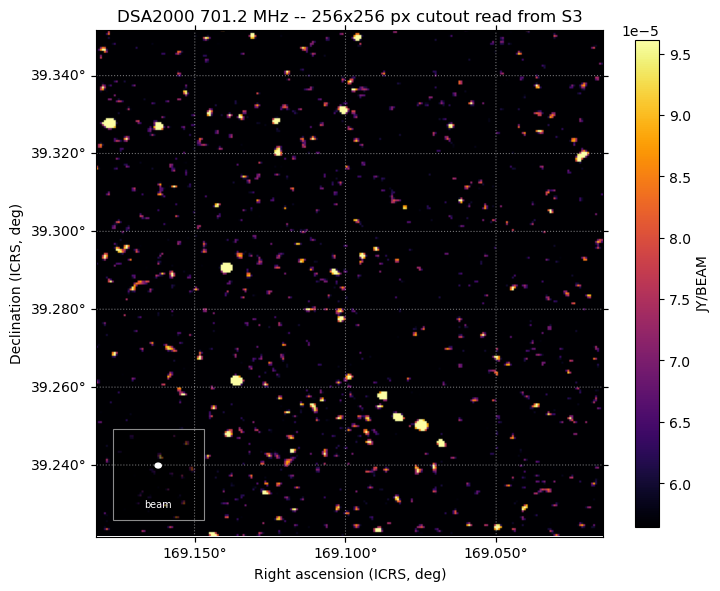

beam is 3.1 x 2.4 pixels


In [8]:
import matplotlib.pyplot as plt
import astropy.units as u
from matplotlib.patches import Ellipse, Rectangle

vmin, vmax = np.nanpercentile(cutout, [95, 99.5])
cut_wcs = wcs.celestial[y0:y1, x0:x1]

fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(projection=cut_wcs)
im = ax.imshow(cutout, origin="lower", cmap="inferno", vmin=vmin, vmax=vmax)

# Right ascension defaults to hours:minutes:seconds; show both axes in
# decimal degrees instead. Three decimals is about 3.6 arcsec, fine enough
# for a field this size without crowding the labels.
ra, dec = ax.coords[0], ax.coords[1]
ra.set_format_unit(u.deg)
dec.set_format_unit(u.deg)
ra.set_major_formatter("d.ddd")
dec.set_major_formatter("d.ddd")
ra.set_ticks(number=5)
dec.set_ticks(number=5)

ax.set_xlabel("Right ascension (ICRS, deg)")
ax.set_ylabel("Declination (ICRS, deg)")
ax.set_title(f"{hdr['TELESCOP']} {hdr['CRVAL3'] / 1e6:.1f} MHz -- "
             f"{CUTOUT}x{CUTOUT} px cutout read from S3")
ax.grid(color="white", ls=":", alpha=0.45)
fig.colorbar(im, ax=ax, label=hdr["BUNIT"], shrink=0.85)

# The beam is 5.7 x 4.5 arcsec on a 1.83 arcsec grid, so only a few pixels
# across. Draw it on a backing patch so it can be found, sized relative to the
# cutout so it stays proportionate if CUTOUT changes.
bmaj_px = hdr["BMAJ"] / abs(hdr["CDELT1"])
bmin_px = hdr["BMIN"] / abs(hdr["CDELT1"])
pad, box = 0.03 * CUTOUT, 0.18 * CUTOUT
ax.add_patch(Rectangle((pad, pad), box, box, facecolor="black",
                       edgecolor="white", alpha=0.55, lw=0.8))
ax.add_patch(Ellipse((pad + box / 2, pad + box * 0.6), width=bmin_px,
                     height=bmaj_px, angle=hdr["BPA"],
                     facecolor="white", edgecolor="white"))
ax.text(pad + box / 2, pad + box * 0.18, "beam", color="white",
        ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

print(f"beam is {bmaj_px:.1f} x {bmin_px:.1f} pixels")

In [9]:
hdul.close()
print("closed")

closed
